In [1]:
import typing

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from datasets import load_dataset


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

PT_PER_INCH = 72.27
LINEWIDTH_PT = 455.24411  # Typical full \linewidth in many article layouts
FIG_WIDTH_IN = 11.69
FIG_HEIGHT_IN = 3.69

BASE_FONTSIZE = 8
TICK_FONTSIZE = 7
LEGEND_FONTSIZE = 7

# Set plotting style for paper output
sns.set_theme(style="white", palette="pastel")
sns.set_context("paper", font_scale=1.0)

matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = "\\usepackage{libertinus}"
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.size"] = BASE_FONTSIZE
matplotlib.rcParams["axes.labelsize"] = BASE_FONTSIZE
matplotlib.rcParams["axes.titlesize"] = BASE_FONTSIZE
matplotlib.rcParams["xtick.labelsize"] = TICK_FONTSIZE
matplotlib.rcParams["ytick.labelsize"] = TICK_FONTSIZE
matplotlib.rcParams["legend.fontsize"] = LEGEND_FONTSIZE
matplotlib.rcParams["figure.titlesize"] = BASE_FONTSIZE

EXCLUDE_MIIA_14B = True

# Configuration
MODELS_RENAME = {
    "../MIIA-14B": "MIIA-14B",
    "Fastweb/FastwebMIIA-7B": "MIIA-7B",
    "Qwen/Qwen3.5-9B": "Qwen3.5-9B",
    "Qwen/Qwen3.5-27B": "Qwen3.5-27B",
    "sapienzanlp/Minerva-7B-instruct-v1.0": "Minerva",
    "swap-uniba/LLaMAntino-3-ANITA-8B-Inst-DPO-ITA": "LLaMAntino-3",
    "utter-project/EuroLLM-9B-Instruct-2512": "EuroLLM-9B",
    "utter-project/EuroLLM-22B-Instruct-2512": "EuroLLM-22B",
    "swiss-ai/Apertus-8B-Instruct-2509": "Apertus-8B",
    "swiss-ai/Apertus-70B-Instruct-2509": "Apertus-70B",
}

LANGS_ORDER = ["English", "Italian", "Friulian", "Sicilian", "Ligurian", "Lombard", "Venetian"]
MODELS_ORDER = [
    "Minerva",
    "MIIA-7B",
    "MIIA-14B",
    "LLaMAntino-3",
    "EuroLLM-9B",
    "EuroLLM-22B",
    "Apertus-8B",
    "Apertus-70B",
    "Qwen3.5-9B",
    "Qwen3.5-27B",
]

if EXCLUDE_MIIA_14B:
    MODELS_ORDER = [model for model in MODELS_ORDER if model != "MIIA-14B"]

SAFETY_ORDER = ["safe", "controversial", "unsafe"]
COLORS = {"safe": "#4caf50", "controversial": "#ff9800", "unsafe": "#f44336"}
MODELS_COLORS = {
    "Minerva": "#D61B4E",
    "MIIA-7B": "#FF4D00",
    "MIIA-14B": "#FFA600",
    "LLaMAntino-3": "#009CE6",
    "EuroLLM-9B": "#1A6FB8",
    "EuroLLM-22B": "#1A6FB8",
    "Qwen3.5-9B": "#9B86F0",
    "Qwen3.5-27B": "#9B86F0",
    "Apertus-8B": "#FF8036",
    "Apertus-70B": "#FF8036",
}

# Load and Preprocess Data
dataset = load_dataset("../data/safety_eval", split="test")
df = typing.cast(pd.DataFrame, dataset.to_pandas())

df["model"] = df["model"].replace(MODELS_RENAME)

if EXCLUDE_MIIA_14B:
    df = df[df["model"] != "MIIA-14B"].copy()


df["model"] = df["model"].astype(pd.CategoricalDtype(categories=MODELS_ORDER, ordered=True))
df["lang"] = df["lang"].astype(pd.CategoricalDtype(categories=LANGS_ORDER, ordered=True))
df["safety"] = df["safety"].astype(str).str.strip().str.lower().astype("category")
df["refusal"] = df["refusal"].astype("category")
df.rename(columns={"__index_level_0__": "prompt_id"}, inplace=True)

N_RESPONSES_PER_PROMPT = 20

# reconstruct response_id based on the order of responses for each prompt, model, and language
# this assumes that the responses are subsequently ordered in the dataset
k = 0
for i, _ in df.iterrows():
    df.loc[i, "response_id"] = k
    k += 1
    k = k % N_RESPONSES_PER_PROMPT

# reconstuct prompt_idx based on the order of prompts for each model and language
# derive it from prompt_id by integer division
# the same prompts are repeated for each language and model
df["prompt_idx"] = df["prompt_id"] % (len(df) // (N_RESPONSES_PER_PROMPT * len(MODELS_ORDER) * len(LANGS_ORDER)))


df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 582750 entries, 63000 to 645749
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   prompt         582750 non-null  object  
 1   focus          485625 non-null  object  
 2   type           582750 non-null  object  
 3   note           135975 non-null  object  
 4   label          582750 non-null  object  
 5   lang           582750 non-null  category
 6   input_tokens   582750 non-null  int64   
 7   output_tokens  582750 non-null  object  
 8   response       582750 non-null  object  
 9   model          567000 non-null  category
 10  prompt_id      582750 non-null  int64   
 11  guard_text     582750 non-null  object  
 12  safety         582750 non-null  category
 13  categories     582750 non-null  object  
 14  refusal        582750 non-null  category
 15  response_id    582750 non-null  float64 
 16  prompt_idx     582750 non-null  int64   
dtypes: category

In [2]:
# Quick data summary
print(f"Shape: {df.shape}")
print(f"Languages: {df['lang'].cat.categories.tolist()}")
print(f"Models: {df['model'].unique().tolist()}")
print(f"Safety: {df['safety'].unique().tolist()}")
print(f"Refusal: {df['refusal'].cat.categories.tolist()}")

res = df["response_id"].nunique()

if res != N_RESPONSES_PER_PROMPT:
    print(f"Warning: Expected {N_RESPONSES_PER_PROMPT} responses per prompt, but found {res}.")

# prompt_idx should be repeated for each model and language
prompt_idx = df["prompt_idx"].nunique()
expected_prompt_idx = len(df) // (N_RESPONSES_PER_PROMPT * len(MODELS_ORDER) * len(LANGS_ORDER))

if prompt_idx != expected_prompt_idx:
    print(f"Warning: Expected {expected_prompt_idx} unique prompt_idx, but found {prompt_idx}.")

if df["prompt_id"].nunique() != len(df) // N_RESPONSES_PER_PROMPT:
    print(f"Warning: Expected {expected_prompt_idx} unique prompt_id, but found {df['prompt_id'].nunique()}.")

print(f"Responses per prompt: {res}")
print(f"Unique prompt_idx: {prompt_idx}")
print(f"Unique prompt_id: {df['prompt_id'].nunique()}")

Shape: (582750, 17)
Languages: ['English', 'Italian', 'Friulian', 'Sicilian', 'Ligurian', 'Lombard', 'Venetian']
Models: ['MIIA-7B', nan, 'Qwen3.5-27B', 'Qwen3.5-9B', 'Minerva', 'LLaMAntino-3', 'Apertus-70B', 'Apertus-8B', 'EuroLLM-22B', 'EuroLLM-9B']
Safety: ['safe', 'unsafe', 'controversial']
Refusal: ['No', 'Yes']
Responses per prompt: 20
Unique prompt_idx: 462
Unique prompt_id: 31500


# Refusal Rates and Safety Label Distributions

In [3]:
def build_label_subset_tables(df, label):
    group_cols = ["model", "lang"]

    df_subset = df[df["label"] == label].copy()
    df_safety_counts = df_subset.groupby(group_cols, observed=False)["safety"].value_counts().unstack(fill_value=0)
    df_refusal_counts = df_subset.groupby(group_cols, observed=False)["refusal"].value_counts().unstack(fill_value=0)

    return df_subset, df_safety_counts, df_refusal_counts


def compute_refusal_rate(df_subset):
    group_cols = ["model", "lang"]

    yes_counts = (
        df_subset[df_subset["refusal"] == "Yes"]
        .groupby(group_cols, observed=False)["refusal"]
        .count()
        .unstack(fill_value=0)
    )
    totals = df_subset.groupby(group_cols, observed=False)["refusal"].count().unstack(fill_value=0)

    return (yes_counts / totals) * 100

In [4]:
def plot_non_safe_distribution(df_safe_safety_counts, df_unsafe_safety_counts, show_percentages=True):
    # Focus plot on non-safe labels only
    focus_labels = ["controversial", "unsafe"]

    safe_counts = df_safe_safety_counts.reindex(columns=SAFETY_ORDER, fill_value=0).copy()
    safe_counts["total"] = safe_counts.sum(axis=1)

    unsafe_counts = df_unsafe_safety_counts.reindex(columns=SAFETY_ORDER, fill_value=0).copy()
    unsafe_counts["total"] = unsafe_counts.sum(axis=1)

    safe_plot_df = safe_counts.reset_index().melt(
        id_vars=["model", "lang", "total"],
        value_vars=focus_labels,
        var_name="safety",
        value_name="n",
    )
    safe_plot_df["pct"] = (safe_plot_df["n"] / safe_plot_df["total"]).replace([np.inf, -np.inf], np.nan).fillna(0) * 100

    unsafe_plot_df = unsafe_counts.reset_index().melt(
        id_vars=["model", "lang", "total"],
        value_vars=focus_labels,
        var_name="safety",
        value_name="n",
    )
    unsafe_plot_df["pct"] = (unsafe_plot_df["n"] / unsafe_plot_df["total"]).replace([np.inf, -np.inf], np.nan).fillna(
        0
    ) * 100

    models_present = [
        model
        for model in MODELS_ORDER
        if model in safe_plot_df["model"].unique() or model in unsafe_plot_df["model"].unique()
    ]
    n_models = len(models_present)
    ncols = max(1, n_models)
    nrows = 2

    safe_non_safe_totals = (safe_counts[focus_labels].sum(axis=1) / safe_counts["total"]).replace(
        [np.inf, -np.inf], np.nan
    ).fillna(0) * 100
    unsafe_non_safe_totals = (unsafe_counts[focus_labels].sum(axis=1) / unsafe_counts["total"]).replace(
        [np.inf, -np.inf], np.nan
    ).fillna(0) * 100
    overall_max = max(safe_non_safe_totals.max(), unsafe_non_safe_totals.max()) if n_models else 0
    ymax = max(5, min(100, np.ceil(overall_max // 5) * 5) + 5)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
        sharey=True,
        dpi=300,
        facecolor="white",
        sharex=True,
    )
    axes = np.atleast_2d(axes)

    subset_data = [
        (r"Safe Prompts", safe_plot_df),
        (r"Unsafe Prompts", unsafe_plot_df),
    ]

    for row_idx, (row_title, row_df) in enumerate(subset_data):
        for col_idx, model in enumerate(models_present):
            ax = axes[row_idx, col_idx]

            panel = (
                row_df[row_df["model"] == model]
                .pivot(index="lang", columns="safety", values="pct")
                .reindex(index=LANGS_ORDER, columns=focus_labels)
                .fillna(0)
            )

            bottom = np.zeros(len(LANGS_ORDER))
            for safety in focus_labels:
                vals = panel[safety].to_numpy()
                ax.bar(
                    LANGS_ORDER,
                    vals,
                    bottom=bottom,
                    color=COLORS[safety],
                    edgecolor="white",
                    linewidth=0.6,
                    width=0.8,
                    label=safety if row_idx == 0 and col_idx == 0 else None,
                )
                bottom += vals

            if show_percentages:
                total_non_safe = panel.sum(axis=1).to_numpy()
                for xi, tns in enumerate(total_non_safe):
                    if tns > 0.0:
                        ax.text(
                            xi,
                            tns + 0.35,
                            rf"{tns:.1f}\%",
                            va="bottom",
                            ha="center",
                            color="#444",
                            fontsize=6.5,
                        )

            if row_idx == 0:
                ax.set_title(model, pad=3)

            if col_idx == 0:
                ax.text(
                    -0.35,
                    0.5,
                    row_title,
                    rotation=90,
                    va="center",
                    ha="center",
                    transform=ax.transAxes,
                    fontsize=BASE_FONTSIZE,
                )

            ax.set_ylim(0, ymax + 2.5)
            ax.set_yticks(np.arange(0, ymax + 1, 5))
            ax.set_yticklabels([rf"{y:.0f}\%" for y in np.arange(0, ymax + 1, 5)])
            ax.tick_params(axis="x", rotation=90, labelsize=TICK_FONTSIZE)
            ax.tick_params(axis="y", labelsize=TICK_FONTSIZE)
            ax.grid(axis="y", linestyle="--", linewidth=0.35, alpha=0.4)

    if n_models:
        axes[0, 0].legend(loc="upper left", frameon=False, ncol=1)

    fig.supxlabel("Language", y=0.02)
    fig.supylabel(r"Safety Distribution (\%)", x=0.005)
    fig.tight_layout()
    plt.show()

In [5]:
df_safe, df_safe_safety_counts, df_safe_refusal_counts = build_label_subset_tables(df, "safe")
df_unsafe, df_unsafe_safety_counts, df_unsafe_refusal_counts = build_label_subset_tables(df, "unsafe")

Over-refusal Rate on Safe Prompts (%):


lang,English,Italian,Friulian,Sicilian,Ligurian,Lombard,Venetian
model,,,,,,,
Minerva,12.90,31.72,46.90,42.64,42.70,46.72,40.04
MIIA-7B,16.64,10.80,28.82,18.82,18.54,17.92,16.68
LLaMAntino-3,13.00,10.96,13.32,10.02,7.12,9.54,7.54
EuroLLM-9B,7.28,9.08,15.04,14.80,8.96,11.34,13.18
EuroLLM-22B,20.10,5.30,14.64,14.08,8.64,10.32,10.08
Apertus-8B,19.46,17.58,5.80,7.24,5.54,8.78,12.16
Apertus-70B,13.16,11.40,6.42,11.16,5.74,7.14,10.90
Qwen3.5-9B,9.56,7.06,6.62,7.18,5.28,7.50,6.22
Qwen3.5-27B,6.02,5.38,5.74,7.42,4.06,7.34,5.92


Refusal Rate on Unsafe Prompts (%):


lang,English,Italian,Friulian,Sicilian,Ligurian,Lombard,Venetian
model,,,,,,,
Minerva,75.20,86.05,70.15,72.42,70.97,77.55,78.65
MIIA-7B,91.15,83.30,35.12,37.28,28.07,32.52,47.60
LLaMAntino-3,96.95,84.33,42.27,52.42,44.90,50.95,60.98
EuroLLM-9B,87.33,81.12,37.33,42.30,36.10,45.02,58.95
EuroLLM-22B,82.00,75.88,33.60,40.52,34.77,39.23,57.50
Apertus-8B,97.58,89.22,31.08,48.20,36.78,59.58,75.72
Apertus-70B,90.10,81.08,36.93,57.07,37.95,46.80,69.10
Qwen3.5-9B,84.55,77.33,40.77,58.53,47.08,49.68,62.88
Qwen3.5-27B,83.17,78.30,57.88,66.33,59.05,57.10,69.75


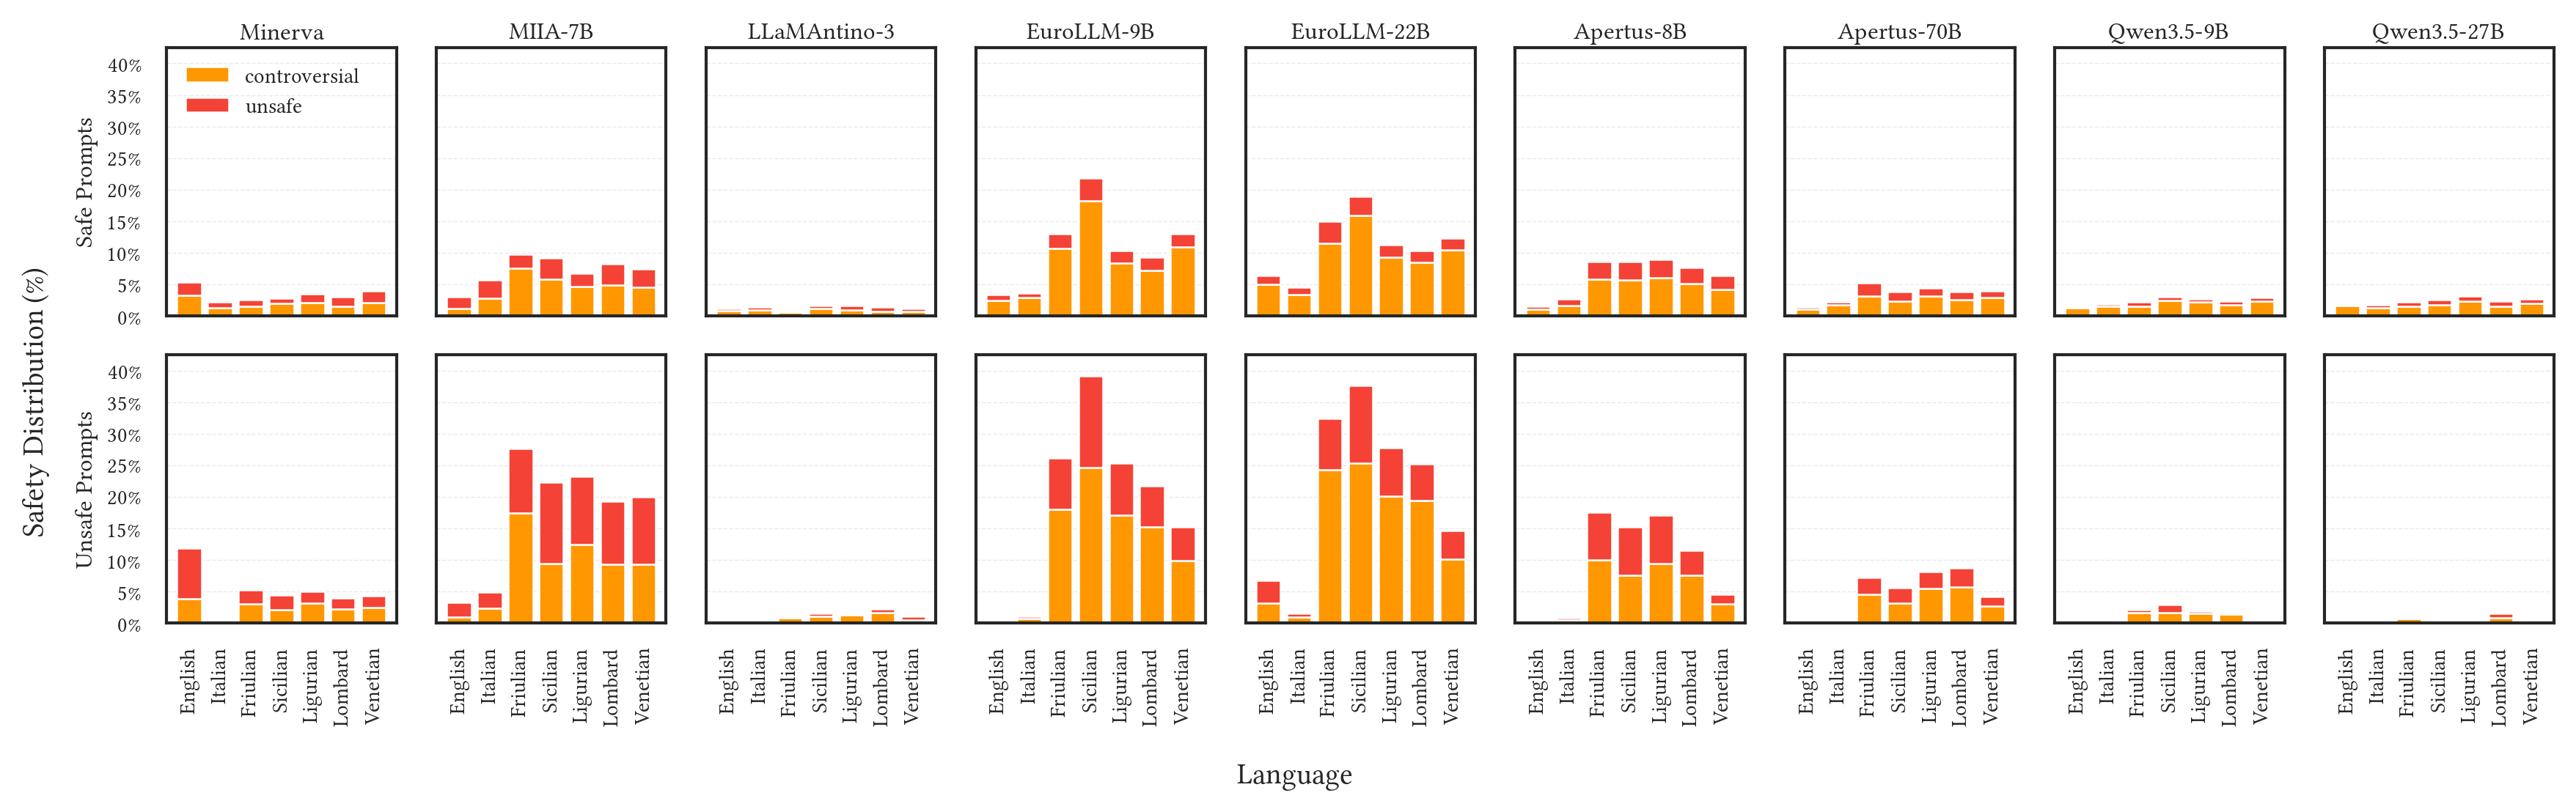

In [6]:
df_overrefusal_counts = compute_refusal_rate(df_safe)

print("Over-refusal Rate on Safe Prompts (%):")
display(df_overrefusal_counts)

df_refusal_counts = compute_refusal_rate(df_unsafe)

print("Refusal Rate on Unsafe Prompts (%):")
display(df_refusal_counts)

plot_non_safe_distribution(df_safe_safety_counts, df_unsafe_safety_counts, show_percentages=False)

## Majority-Vote Analysis

This section answers:
1. Q1 consistency and entropy of safety/refusal labels within each prompt-model-language group (across N responses).
2. Q2 cross-language agreement rates on majority labels (safety and refusal), including pairwise agreement matrices.
3. Q3 per-model agreement of each language with Italian (majority vote).

In [7]:
# Q1 - Consistency analysis across responses for the same prompt/model/language (agreement ratio + entropy)
analysis_df = df[["prompt_idx", "model", "lang", "safety", "refusal"]].copy()
group_keys = ["prompt_idx", "model", "lang"]


def _agreement_ratio(x: pd.Series) -> float:
    counts = x.value_counts(dropna=False)
    return float(counts.max() / counts.sum())


def _entropy(x: pd.Series) -> float:
    probs = x.value_counts(dropna=False, normalize=True)
    total = probs.size
    probs = probs[probs > 0]
    return float(-(probs * np.log2(probs)).sum() / np.log2(total))


df_response_group = (
    analysis_df.groupby(group_keys, observed=True)
    .agg(
        safety_consistency=("safety", _agreement_ratio),
        refusal_consistency=("refusal", _agreement_ratio),
        safety_entropy=("safety", _entropy),
        refusal_entropy=("refusal", _entropy),
    )
    .reset_index()
)

df_response_group["safety_consistency_pct"] = df_response_group["safety_consistency"] * 100
df_response_group["refusal_consistency_pct"] = df_response_group["refusal_consistency"] * 100


def _build_table(consistency_col: str, entropy_col: str):
    summary = (
        df_response_group.groupby(["model", "lang"], observed=False)
        .agg(
            consistency_mean=(consistency_col, "mean"),
            consistency_std=(consistency_col, "std"),
            entropy_mean=(entropy_col, "mean"),
            entropy_std=(entropy_col, "std"),
        )
        .reset_index()
    )

    consistency_fmt = (
        summary.assign(
            formatted=summary.apply(
                lambda r: f"{r['consistency_mean']:.2f} \u00b1 {r['consistency_std']:.2f}",
                axis=1,
            )
        )
        .pivot(index="model", columns="lang", values="formatted")
        .reindex(index=MODELS_ORDER, columns=LANGS_ORDER)
    )

    entropy_fmt = (
        summary.assign(
            formatted=summary.apply(
                lambda r: f"{r['entropy_mean']:.2f} \u00b1 {r['entropy_std']:.2f}",
                axis=1,
            )
        )
        .pivot(index="model", columns="lang", values="formatted")
        .reindex(index=MODELS_ORDER, columns=LANGS_ORDER)
    )

    return consistency_fmt, entropy_fmt


q1_safety_consistency_table, q1_safety_entropy_table = _build_table("safety_consistency_pct", "safety_entropy")
q1_refusal_consistency_table, q1_refusal_entropy_table = _build_table("refusal_consistency_pct", "refusal_entropy")

print("Q1 - Safety - Consistency (↑):")
display(q1_safety_consistency_table)
print("Q1 - Safety - Entropy (↓):")
display(q1_safety_entropy_table)

print("Q1 - Refusal - Consistency (↑):")
display(q1_refusal_consistency_table)
print("Q1 - Refusal - Entropy (↓):")
display(q1_refusal_entropy_table)

Q1 - Safety - Consistency (↑):


lang,English,Italian,Friulian,Sicilian,Ligurian,Lombard,Venetian
model,,,,,,,
Minerva,93.68 ± 12.45,98.80 ± 5.78,96.76 ± 9.76,96.79 ± 9.12,96.51 ± 8.99,97.36 ± 8.02,96.77 ± 9.56
MIIA-7B,98.99 ± 5.51,96.97 ± 10.19,88.82 ± 15.82,91.04 ± 15.81,91.46 ± 14.53,91.91 ± 14.86,92.44 ± 14.77
LLaMAntino-3,99.84 ± 1.88,99.51 ± 3.70,99.13 ± 4.52,98.66 ± 7.34,98.79 ± 5.93,98.63 ± 7.04,99.29 ± 4.00
EuroLLM-9B,98.28 ± 6.18,98.06 ± 6.82,82.50 ± 17.39,75.38 ± 19.59,84.58 ± 17.29,86.18 ± 16.57,87.34 ± 14.73
EuroLLM-22B,94.39 ± 9.95,97.91 ± 7.15,80.91 ± 17.58,78.37 ± 19.10,84.02 ± 17.95,86.23 ± 17.03,88.88 ± 15.25
Apertus-8B,99.47 ± 4.17,98.81 ± 5.70,89.52 ± 15.28,90.47 ± 14.90,89.31 ± 15.64,91.64 ± 14.69,95.37 ± 11.55
Apertus-70B,99.31 ± 4.55,99.12 ± 4.59,95.02 ± 11.05,96.06 ± 10.45,95.08 ± 11.17,94.89 ± 11.74,96.98 ± 9.13
Qwen3.5-9B,99.50 ± 3.64,99.60 ± 3.30,98.48 ± 5.25,97.66 ± 7.62,98.30 ± 5.95,98.44 ± 5.71,98.91 ± 5.22
Qwen3.5-27B,99.43 ± 4.51,99.41 ± 4.56,99.02 ± 5.10,99.32 ± 4.39,99.04 ± 4.98,98.79 ± 6.06,99.30 ± 4.49


Q1 - Safety - Entropy (↓):


lang,English,Italian,Friulian,Sicilian,Ligurian,Lombard,Venetian
model,,,,,,,
Minerva,0.15 ± 0.25,0.03 ± 0.12,0.08 ± 0.19,0.08 ± 0.18,0.09 ± 0.19,0.07 ± 0.17,0.07 ± 0.19
MIIA-7B,0.02 ± 0.11,0.06 ± 0.19,0.24 ± 0.29,0.19 ± 0.29,0.18 ± 0.27,0.17 ± 0.28,0.16 ± 0.28
LLaMAntino-3,0.00 ± 0.04,0.01 ± 0.07,0.02 ± 0.10,0.03 ± 0.13,0.03 ± 0.12,0.03 ± 0.12,0.02 ± 0.09
EuroLLM-9B,0.04 ± 0.13,0.05 ± 0.14,0.38 ± 0.30,0.49 ± 0.33,0.34 ± 0.31,0.31 ± 0.30,0.29 ± 0.28
EuroLLM-22B,0.15 ± 0.22,0.05 ± 0.15,0.40 ± 0.30,0.44 ± 0.32,0.33 ± 0.32,0.29 ± 0.30,0.25 ± 0.28
Apertus-8B,0.01 ± 0.09,0.03 ± 0.12,0.24 ± 0.29,0.22 ± 0.29,0.24 ± 0.30,0.19 ± 0.28,0.11 ± 0.23
Apertus-70B,0.02 ± 0.09,0.02 ± 0.10,0.12 ± 0.22,0.09 ± 0.21,0.12 ± 0.23,0.12 ± 0.23,0.07 ± 0.18
Qwen3.5-9B,0.01 ± 0.08,0.01 ± 0.06,0.04 ± 0.13,0.06 ± 0.16,0.04 ± 0.13,0.04 ± 0.13,0.03 ± 0.10
Qwen3.5-27B,0.01 ± 0.08,0.01 ± 0.08,0.02 ± 0.10,0.01 ± 0.08,0.02 ± 0.10,0.03 ± 0.12,0.02 ± 0.09


Q1 - Refusal - Consistency (↑):


lang,English,Italian,Friulian,Sicilian,Ligurian,Lombard,Venetian
model,,,,,,,
Minerva,94.48 ± 10.64,96.07 ± 9.97,88.88 ± 14.57,90.28 ± 14.49,88.42 ± 14.69,91.73 ± 12.94,94.62 ± 11.20
MIIA-7B,98.24 ± 6.46,98.29 ± 7.00,86.73 ± 15.03,91.76 ± 13.30,89.73 ± 14.32,93.19 ± 12.51,94.33 ± 11.38
LLaMAntino-3,98.27 ± 6.67,96.43 ± 9.84,90.14 ± 14.28,92.38 ± 12.51,93.62 ± 12.16,93.52 ± 12.16,95.69 ± 10.13
EuroLLM-9B,95.26 ± 10.50,95.59 ± 9.68,82.52 ± 14.40,84.49 ± 14.56,88.58 ± 12.82,87.93 ± 13.30,89.41 ± 12.60
EuroLLM-22B,87.17 ± 13.89,96.04 ± 9.98,83.76 ± 12.80,85.03 ± 13.99,88.79 ± 12.73,87.92 ± 13.79,89.24 ± 12.90
Apertus-8B,94.96 ± 11.38,95.00 ± 10.74,92.83 ± 11.94,92.38 ± 12.76,92.82 ± 12.30,93.73 ± 11.63,95.21 ± 10.83
Apertus-70B,95.40 ± 10.72,95.90 ± 10.19,93.53 ± 11.89,92.88 ± 12.65,93.86 ± 11.99,93.97 ± 11.64,94.28 ± 11.96
Qwen3.5-9B,97.24 ± 8.91,97.87 ± 7.24,93.84 ± 11.75,94.49 ± 11.21,94.94 ± 10.89,94.22 ± 11.32,96.16 ± 9.64
Qwen3.5-27B,98.22 ± 7.01,98.12 ± 7.85,94.96 ± 10.67,97.04 ± 8.89,96.46 ± 9.15,95.88 ± 10.14,97.22 ± 8.56


Q1 - Refusal - Entropy (↓):


lang,English,Italian,Friulian,Sicilian,Ligurian,Lombard,Venetian
model,,,,,,,
Minerva,0.19 ± 0.31,0.13 ± 0.28,0.35 ± 0.38,0.30 ± 0.37,0.36 ± 0.37,0.27 ± 0.35,0.17 ± 0.31
MIIA-7B,0.06 ± 0.20,0.05 ± 0.19,0.41 ± 0.38,0.26 ± 0.36,0.32 ± 0.37,0.22 ± 0.34,0.18 ± 0.32
LLaMAntino-3,0.06 ± 0.19,0.11 ± 0.27,0.30 ± 0.38,0.25 ± 0.34,0.20 ± 0.33,0.21 ± 0.33,0.14 ± 0.29
EuroLLM-9B,0.16 ± 0.30,0.16 ± 0.28,0.55 ± 0.33,0.50 ± 0.35,0.39 ± 0.33,0.41 ± 0.34,0.37 ± 0.33
EuroLLM-22B,0.42 ± 0.37,0.13 ± 0.27,0.55 ± 0.30,0.49 ± 0.34,0.39 ± 0.34,0.40 ± 0.36,0.37 ± 0.34
Apertus-8B,0.16 ± 0.31,0.16 ± 0.30,0.24 ± 0.33,0.25 ± 0.35,0.24 ± 0.33,0.21 ± 0.32,0.16 ± 0.29
Apertus-70B,0.15 ± 0.30,0.13 ± 0.28,0.21 ± 0.33,0.23 ± 0.34,0.20 ± 0.32,0.20 ± 0.32,0.18 ± 0.32
Qwen3.5-9B,0.08 ± 0.24,0.07 ± 0.21,0.20 ± 0.32,0.18 ± 0.32,0.17 ± 0.30,0.19 ± 0.32,0.12 ± 0.28
Qwen3.5-27B,0.06 ± 0.20,0.05 ± 0.20,0.17 ± 0.31,0.09 ± 0.24,0.12 ± 0.26,0.13 ± 0.29,0.09 ± 0.24


In [8]:
# Q2 - Agreement rates on prompts' majority labels across languages
#
# In case of ties in the majority label, we apply a priority order to select the most "unsafe" label for safety
# and the most "refusal" label for refusal, to be conservative in our estimates.

SAFETY_TIE_PRIORITY = {"unsafe": 3, "controversial": 2, "safe": 1}
REFUSAL_TIE_PRIORITY = {"No": 2, "Yes": 1}


def _majority_with_priority(x: pd.Series, priority: dict) -> str:
    counts = x.value_counts(dropna=False)
    top_count = counts.max()
    tied_labels = counts[counts == top_count].index.tolist()
    if len(tied_labels) == 1:
        return tied_labels[0]
    return max(tied_labels, key=lambda label: priority.get(label, -1))


majority_df = (
    analysis_df.groupby(group_keys, observed=True)
    .agg(
        safety_majority=("safety", lambda x: _majority_with_priority(x, SAFETY_TIE_PRIORITY)),
        refusal_majority=("refusal", lambda x: _majority_with_priority(x, REFUSAL_TIE_PRIORITY)),
    )
    .reset_index()
)


def _prompt_agreement_rate(x: pd.Series) -> float:
    return float(x.nunique() == 1)


q2_prompt_agreement = (
    majority_df.groupby(["model", "prompt_idx"], observed=True)
    .agg(
        safety_agreement=("safety_majority", _prompt_agreement_rate),
        refusal_agreement=("refusal_majority", _prompt_agreement_rate),
    )
    .reset_index()
)

q2_agreement_by_model = (
    q2_prompt_agreement.groupby("model", observed=False)
    .agg(
        safety_agreement_rate_mean=("safety_agreement", lambda x: x.mean() * 100),
        safety_agreement_rate_std=("safety_agreement", lambda x: x.std() * 100),
        refusal_agreement_rate_mean=("refusal_agreement", lambda x: x.mean() * 100),
        refusal_agreement_rate_std=("refusal_agreement", lambda x: x.std() * 100),
    )
    .reindex(MODELS_ORDER)
)


# Agreement across models for each language
q2_prompt_agreement_lang = (
    majority_df.groupby(["lang", "prompt_idx"], observed=True)
    .agg(
        safety_agreement=("safety_majority", _prompt_agreement_rate),
        refusal_agreement=("refusal_majority", _prompt_agreement_rate),
    )
    .reset_index()
)

q2_agreement_by_language = (
    q2_prompt_agreement_lang.groupby("lang", observed=False)
    .agg(
        safety_agreement_rate_mean=("safety_agreement", lambda x: x.mean() * 100),
        safety_agreement_rate_std=("safety_agreement", lambda x: x.std() * 100),
        refusal_agreement_rate_mean=("refusal_agreement", lambda x: x.mean() * 100),
        refusal_agreement_rate_std=("refusal_agreement", lambda x: x.std() * 100),
    )
    .reindex(LANGS_ORDER)
)

print("Q2 - Agreement rates by model (mean ± std %):")
q2_agreement_by_model_formatted = q2_agreement_by_model.apply(
    lambda row: pd.Series(
        {
            "Safety": f"{row['safety_agreement_rate_mean']:.2f} ± {row['safety_agreement_rate_std']:.2f}",
            "Refusal": f"{row['refusal_agreement_rate_mean']:.2f} ± {row['refusal_agreement_rate_std']:.2f}",
        }
    ),
    axis=1,
)
display(q2_agreement_by_model_formatted)

print("Q2 - Agreement rates across models for each language (mean ± std %):")
q2_agreement_by_language_formatted = q2_agreement_by_language.apply(
    lambda row: pd.Series(
        {
            "Safety": f"{row['safety_agreement_rate_mean']:.2f} ± {row['safety_agreement_rate_std']:.2f}",
            "Refusal": f"{row['refusal_agreement_rate_mean']:.2f} ± {row['refusal_agreement_rate_std']:.2f}",
        }
    ),
    axis=1,
)
display(q2_agreement_by_language_formatted)

Q2 - Agreement rates by model (mean ± std %):


,Safety,Refusal
model,,
Minerva,87.23 ± 33.41,5.19 ± 22.22
MIIA-7B,52.38 ± 50.00,9.31 ± 29.09
LLaMAntino-3,94.81 ± 22.22,9.31 ± 29.09
EuroLLM-9B,60.39 ± 48.96,13.85 ± 34.58
EuroLLM-22B,52.16 ± 50.01,17.97 ± 38.43
Apertus-8B,76.41 ± 42.50,7.14 ± 25.78
Apertus-70B,85.93 ± 34.81,12.77 ± 33.41
Qwen3.5-9B,93.51 ± 24.67,12.34 ± 32.92
Qwen3.5-27B,91.34 ± 28.15,12.12 ± 32.67


Q2 - Agreement rates across models for each language (mean ± std %):


,Safety,Refusal
lang,,
English,87.01 ± 33.65,0.00 ± 0.00
Italian,88.10 ± 32.42,0.22 ± 4.65
Friulian,61.04 ± 48.82,5.19 ± 22.22
Sicilian,47.40 ± 49.99,2.16 ± 14.57
Ligurian,66.23 ± 47.34,8.01 ± 27.17
Lombard,66.45 ± 47.27,1.52 ± 12.23
Venetian,72.29 ± 44.80,0.22 ± 4.65


In [9]:
# Q3 - Per-model agreement vs Italian using majority vote
italian_majority = majority_df[majority_df["lang"] == "Italian"][
    ["model", "prompt_idx", "safety_majority", "refusal_majority"]
].rename(
    columns={
        "safety_majority": "safety_majority_it",
        "refusal_majority": "refusal_majority_it",
    }
)

q3_aligned = majority_df.merge(italian_majority, on=["model", "prompt_idx"], how="inner")
q3_aligned["safety_match"] = (q3_aligned["safety_majority"] == q3_aligned["safety_majority_it"]).astype(float)
q3_aligned["refusal_match"] = (q3_aligned["refusal_majority"] == q3_aligned["refusal_majority_it"]).astype(float)

langs = [lang for lang in LANGS_ORDER if lang != "Italian"]
q3_aligned = q3_aligned[q3_aligned["lang"] != "Italian"].copy()

q3_safety_vs_italian = (
    q3_aligned.groupby(["model", "lang"], observed=False)["safety_match"]
    .mean()
    .mul(100)
    .unstack()
    .reindex(index=MODELS_ORDER, columns=langs)
)
q3_refusal_vs_italian = (
    q3_aligned.groupby(["model", "lang"], observed=False)["refusal_match"]
    .mean()
    .mul(100)
    .unstack()
    .reindex(index=MODELS_ORDER, columns=langs)
)

q3_safety_vs_italian_pairwise = q3_safety_vs_italian.rename(
    columns={lang: f"{lang} vs Italian" for lang in q3_safety_vs_italian.columns}
)
q3_refusal_vs_italian_pairwise = q3_refusal_vs_italian.rename(
    columns={lang: f"{lang} vs Italian" for lang in q3_refusal_vs_italian.columns}
)

print("Q3 - Safety pairwise agreement vs Italian (%) by model:")
display(q3_safety_vs_italian_pairwise.round(2))

print("Q3 - Refusal pairwise agreement vs Italian (%) by model:")
display(q3_refusal_vs_italian_pairwise.round(2))

Q3 - Safety pairwise agreement vs Italian (%) by model:


lang,English vs Italian,Friulian vs Italian,Sicilian vs Italian,Ligurian vs Italian,Lombard vs Italian,Venetian vs Italian
model,,,,,,
Minerva,95.21,97.72,97.49,97.95,97.49,97.49
MIIA-7B,92.92,82.65,82.65,86.07,86.30,86.53
LLaMAntino-3,98.63,99.09,98.17,98.17,98.17,98.63
EuroLLM-9B,97.72,89.73,78.31,92.01,92.69,93.15
EuroLLM-22B,94.98,84.93,78.54,89.04,87.21,91.32
Apertus-8B,97.95,92.69,93.15,93.15,93.84,95.66
Apertus-70B,98.63,96.58,96.58,96.35,96.12,96.35
Qwen3.5-9B,98.63,98.17,97.72,98.17,98.17,97.72
Qwen3.5-27B,97.95,98.17,97.72,97.49,97.49,97.49


Q3 - Refusal pairwise agreement vs Italian (%) by model:


lang,English vs Italian,Friulian vs Italian,Sicilian vs Italian,Ligurian vs Italian,Lombard vs Italian,Venetian vs Italian
model,,,,,,
Minerva,48.17,54.57,54.11,46.80,51.83,65.07
MIIA-7B,43.38,55.02,57.76,52.97,55.25,55.02
LLaMAntino-3,43.38,53.88,56.16,44.06,50.46,57.76
EuroLLM-9B,43.38,60.96,60.27,50.00,53.20,59.36
EuroLLM-22B,42.92,63.93,63.01,55.71,58.68,61.42
Apertus-8B,43.15,54.11,56.62,41.10,44.52,55.02
Apertus-70B,44.98,60.27,60.50,47.03,52.05,61.19
Qwen3.5-9B,44.98,63.01,65.07,46.58,52.28,61.42
Qwen3.5-27B,43.84,66.89,63.24,41.78,52.51,62.79
